In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

sns.set_style("whitegrid")

In [196]:
df = pd.read_csv('synthetic_student_performance.csv')
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,1,3,16,13,0,2,0,0,0,0,3.158425,1
1,1002,18,1,2,0,17,28,0,2,1,1,1,0,2.794655,2
2,1003,15,1,0,1,13,18,1,4,0,0,0,1,3.774847,0
3,1004,17,1,0,3,6,4,0,3,1,0,0,0,3.040574,1
4,1005,17,0,1,2,6,20,0,4,0,0,0,0,3.382310,1


In [178]:
print("\nThe Missing values:")
print(df.isnull().sum())


The Missing values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [179]:
df['GradeClass'] = 3 - df['GradeClass']
print("GradeClass now reversed to 0=worst, 3=best")

GradeClass now reversed to 0=worst, 3=best


Original GradeClass distribution:
GradeClass
0     650
1    1023
2    1152
3    2175
Name: count, dtype: int64


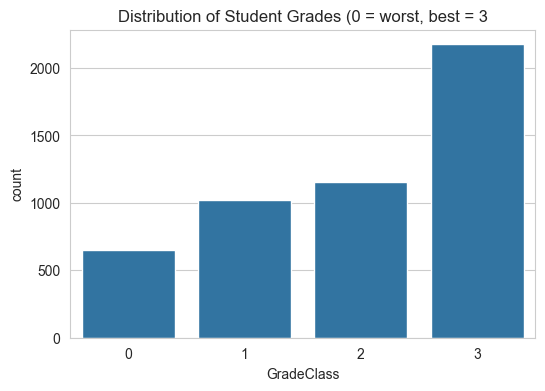

In [180]:
print("Original GradeClass distribution:")
print(df['GradeClass'].value_counts().sort_index())

plt.figure(figsize=(6,4))
sns.countplot(x='GradeClass', data=df)
plt.title('Distribution of Student Grades (0 = worst, best = 3')
plt.show()

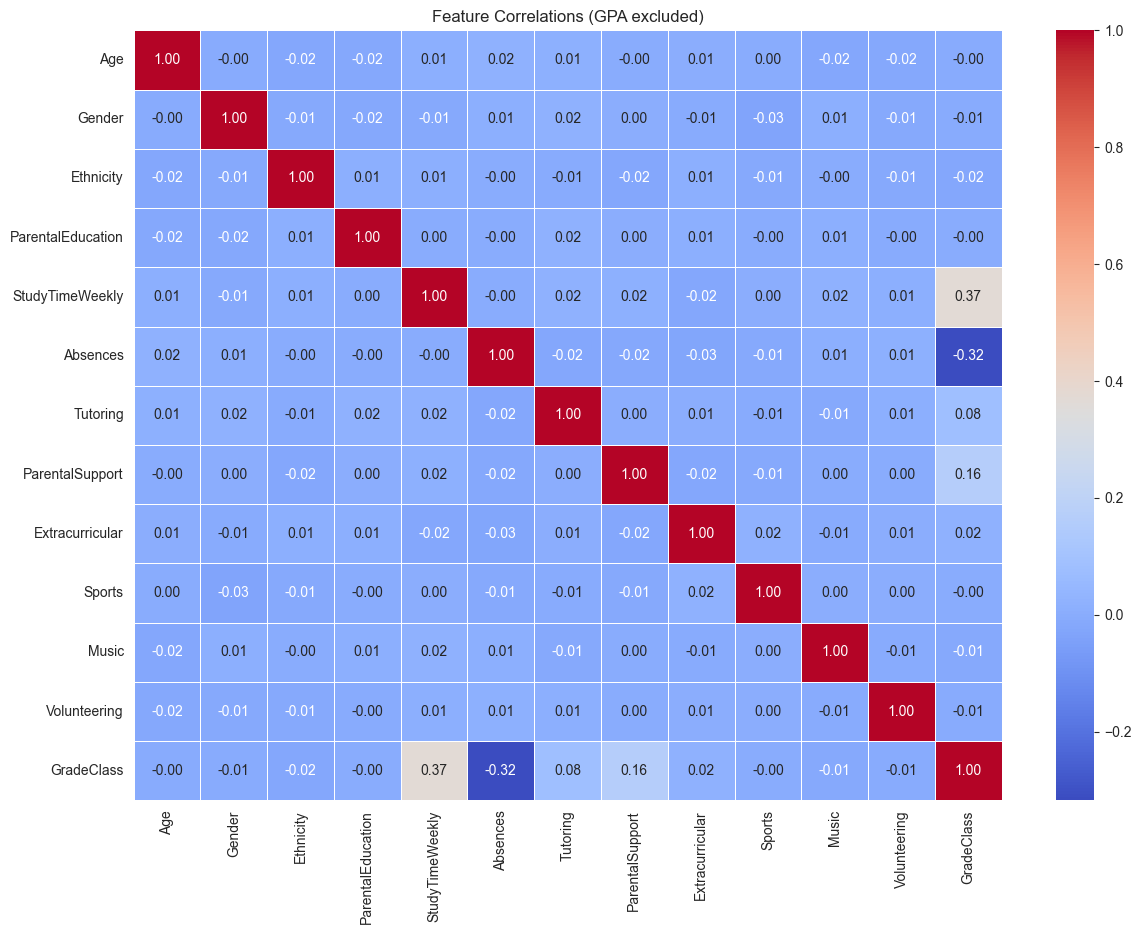

In [181]:
features_for_corr = [col for col in df.columns if col not in ['GPA', 'StudentID']]

plt.figure(figsize=(14,10))
correlation_matrix = df[features_for_corr].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlations (GPA excluded)')
plt.show()

In [182]:
features_for_corr = [col for col in df.columns if col not in ['GPA', 'StudentID', 'GradeClass']]
correlations = df[features_for_corr + ['GradeClass']].corr()['GradeClass'].drop('GradeClass').sort_values(ascending=False)

print("\nAbsolute correlations (strength):")
print(correlations.abs().sort_values(ascending=False))

print("\nCorrelations with GradeClass (GPA excluded):")
print(correlations)


Absolute correlations (strength):
StudyTimeWeekly      0.369837
Absences             0.317774
ParentalSupport      0.161839
Tutoring             0.083080
Ethnicity            0.024139
Extracurricular      0.021584
Music                0.012525
Volunteering         0.007380
Gender               0.006872
Age                  0.004153
ParentalEducation    0.001253
Sports               0.000311
Name: GradeClass, dtype: float64

Correlations with GradeClass (GPA excluded):
StudyTimeWeekly      0.369837
ParentalSupport      0.161839
Tutoring             0.083080
Extracurricular      0.021584
Sports              -0.000311
ParentalEducation   -0.001253
Age                 -0.004153
Gender              -0.006872
Volunteering        -0.007380
Music               -0.012525
Ethnicity           -0.024139
Absences            -0.317774
Name: GradeClass, dtype: float64


The selected 5 most influential features: ['StudyTimeWeekly', 'Absences', 'ParentalSupport', 'Tutoring', 'Ethnicity']

Correlation strengths:
  StudyTimeWeekly: 0.3698
  Absences: -0.3178
  ParentalSupport: 0.1618
  Tutoring: 0.0831
  Ethnicity: -0.0241


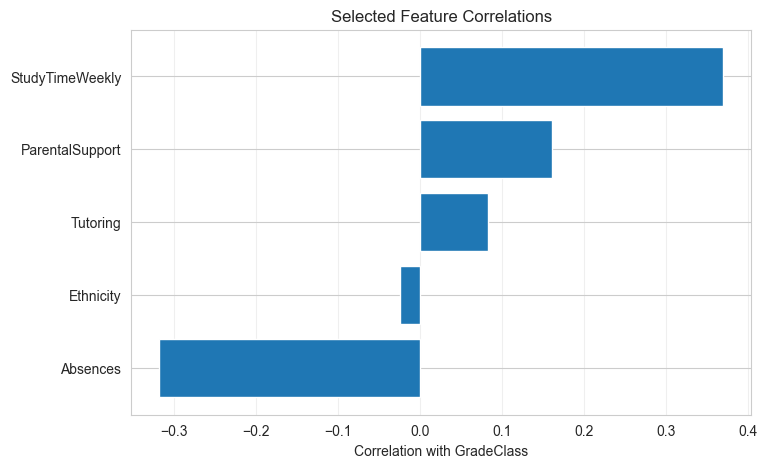

In [183]:
feature_corrs = correlations.abs().sort_values(ascending=False)
selected_features = feature_corrs.head(5).index.tolist()

print(f"The selected 5 most influential features: {selected_features}")
print("\nCorrelation strengths:")
for feature in selected_features:
    print(f"  {feature}: {correlations[feature]:.4f}")


plt.figure(figsize=(8,5))
correlations_selected = correlations[selected_features].sort_values()
plt.barh(correlations_selected.index, correlations_selected.values)
plt.xlabel('Correlation with GradeClass')
plt.title('Selected Feature Correlations')
plt.grid(axis='x', alpha=0.3)
plt.show()

In [184]:
df[selected_features].describe().round(2)

,StudyTimeWeekly,Absences,ParentalSupport,Tutoring,Ethnicity
count,5000.00,5000.00,5000.00,5000.00,5000.00
mean,10.03,15.07,2.30,0.31,0.89
std,6.02,8.92,1.22,0.46,1.04
min,0.00,0.00,0.00,0.00,0.00
25%,5.00,8.00,2.00,0.00,0.00
50%,10.00,15.00,2.00,0.00,0.00
75%,15.00,23.00,3.00,1.00,2.00
max,20.00,30.00,4.00,1.00,3.00


In [185]:
X = df[selected_features]
y = df['GradeClass']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (5000, 5)
Target shape: (5000,)


In [186]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print("\nTraining set class distribution:")
print(y_train.value_counts().sort_index())
print("\nTest set class distribution:")
print(y_test.value_counts().sort_index())


Training samples: 4000
Test samples: 1000

Training set class distribution:
GradeClass
0     520
1     818
2     922
3    1740
Name: count, dtype: int64

Test set class distribution:
GradeClass
0    130
1    205
2    230
3    435
Name: count, dtype: int64


In [187]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled to mean=0, variance=1")
print(f"Training scaled shape: {X_train_scaled.shape}")
print(f"Test scaled shape: {X_test_scaled.shape}")

Features scaled to mean=0, variance=1
Training scaled shape: (4000, 5)
Test scaled shape: (1000, 5)


In [188]:
param_grid = {'C': [0.01, 0.1, 1], 'solver': ['lbfgs', 'saga']}
grid_search = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), 
                           param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("The best parameters:", grid_search.best_params_)
model = grid_search.best_estimator_


The best parameters: {'C': 0.01, 'solver': 'lbfgs'}


In [189]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"The logistic Regression accuracy: {accuracy:.2f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

The logistic Regression accuracy: 0.47

Confusion Matrix:
[[ 59  28   2  41]
 [ 30  22   1 152]
 [ 33  22   0 175]
 [ 10  30   1 394]]

Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.45      0.45       130
           1       0.22      0.11      0.14       205
           2       0.00      0.00      0.00       230
           3       0.52      0.91      0.66       435

    accuracy                           0.47      1000
   macro avg       0.29      0.37      0.31      1000
weighted avg       0.33      0.47      0.37      1000



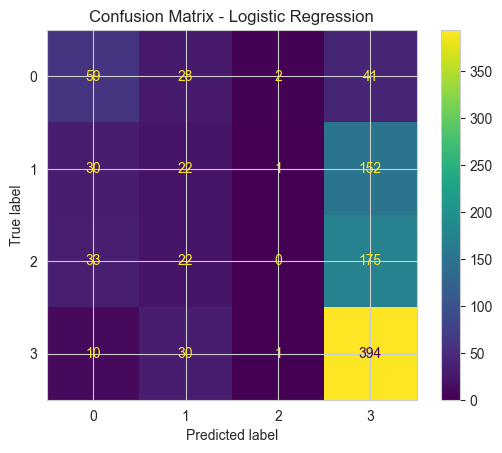

In [190]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [191]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print(f"Cross-validation accuracy: {cv_scores.mean():.2f} (+/- {cv_scores.std():.2f})")

Cross-validation accuracy: 0.48 (+/- 0.02)


In [192]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

print(f"The decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

The decision Tree Accuracy: 0.47

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.42      0.38       130
           1       0.29      0.20      0.23       205
           2       0.15      0.02      0.03       230
           3       0.55      0.84      0.66       435

    accuracy                           0.47      1000
   macro avg       0.33      0.37      0.33      1000
weighted avg       0.38      0.47      0.39      1000



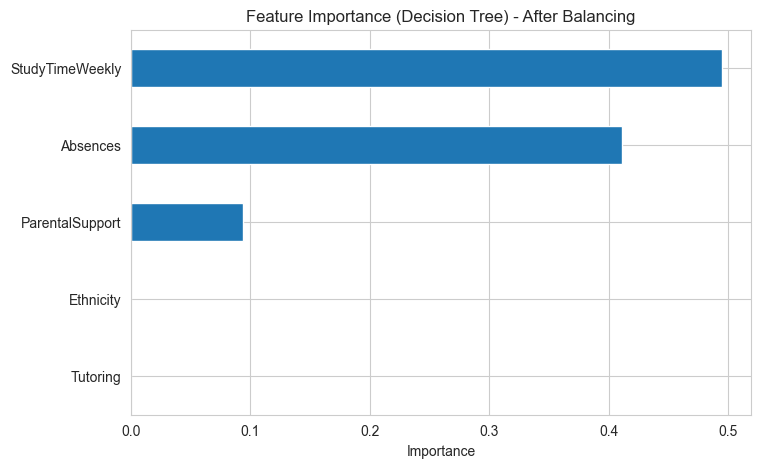


Feature Importance:
StudyTimeWeekly    0.494557
Absences           0.411484
ParentalSupport    0.093959
Tutoring           0.000000
Ethnicity          0.000000
dtype: float64


In [193]:
importances = dt_model.feature_importances_
feat_imp = pd.Series(importances, index=selected_features)
feat_imp.sort_values().plot(kind='barh', figsize=(8,5))
plt.title('Feature Importance (Decision Tree) - After Balancing')
plt.xlabel('Importance')
plt.show()

print("\nFeature Importance:")
print(feat_imp.sort_values(ascending=False))